In [ ]:
from pathlib import Path
import datetime as dt
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import dates as md

In [ ]:
PROJPATH = Path().resolve().parent
breakupfpth = PROJPATH / "data/breakupdata/derived/breakupDate_cleaned_selected.csv"    # breaupdates inclu
brokenuppth = PROJPATH / "data/DDforecast_2025/broken_up_2025.csv"
combindedpth = PROJPATH / "data/weatherstations/ACIS_combined_DD"
locationprefix = "DD25_combined_"
today = dt.datetime.now().strftime("%Y-%m-%d")
daily_reportpth = PROJPATH / f"data/DDforecast_2026/daily_report_{today}.csv"

In [ ]:
daily_report = pd.read_csv(daily_reportpth)
daily_report

,location,river,forecastdate,most likely breakup in (days),forecasted date,average breakup date,probability of breakup within ± 3 days around forecasted,probability of breakup within 1 or 2 days,probability of breakup within 3-7 days,probability of breakup within week 2 from now,probability of breakup within week 3 from now
0,Buckland,Buckland River,2026-04-18,31,2026-05-18,2026-05-17,0.36,0.00,0.00,0.01,0.06
1,Umiat,Colville River,2026-04-18,39,2026-05-26,2026-05-24,0.37,0.00,0.00,0.00,0.01
2,Colville Village,Colville River,2026-04-18,46,2026-06-02,2026-06-01,0.37,0.00,0.00,0.00,0.00
3,Kobuk,Kobuk River,2026-04-18,30,2026-05-17,2026-05-16,0.43,0.00,0.00,0.00,0.06
4,Shungnak,Kobuk River,2026-04-18,31,2026-05-18,2026-05-17,0.43,0.00,0.00,0.00,0.03
5,Ambler,Kobuk River,2026-04-18,32,2026-05-19,2026-05-18,0.42,0.00,0.00,0.00,0.04
6,Allakaket,Koyukuk River,2026-04-18,25,2026-05-12,2026-05-10,0.43,0.00,0.00,0.02,0.18
7,Bettles,Koyukuk River,2026-04-18,24,2026-05-11,2026-05-10,0.42,0.00,0.00,0.04,0.23
8,Hughes,Koyukuk River,2026-04-18,25,2026-05-12,2026-05-11,0.43,0.00,0.00,0.04,0.22
9,Nikolai,Kuskokwim River,2026-04-18,10,2026-04-27,2026-04-23,0.59,0.01,0.18,0.60,0.20


In [ ]:
breakup = pd.read_csv(breakupfpth, skiprows=3, index_col=0)
breakup

,id,siteID,year,breakup,JulianDay
1894,209,Buckland River at Buckland,1983,1983-05-12,132
1866,210,Buckland River at Buckland,1984,1984-05-23,144
1829,1067,Buckland River at Buckland,1985,1985-05-26,146
1780,211,Buckland River at Buckland,1986,1986-05-30,150
1741,212,Buckland River at Buckland,1987,1987-05-22,142
...,...,...,...,...,...
227,7081,Yukon River nr Emmonak,2021,2021-05-13,133
176,7160,Yukon River nr Emmonak,2022,2022-05-15,135
143,7236,Yukon River nr Emmonak,2023,2023-05-27,147
83,7294,Yukon River nr Emmonak,2024,2023-05-24,144


In [ ]:
siteIDs = breakup.siteID.unique()
testsite = 'Kuskokwim River at Nikolai'
# testsite = 'Tanana River at Nenana'
# testsite = 'Buckland River at Buckland'
testsite = 'Yukon River at Galena'  

In [ ]:
def get_testdd(testsite):
    """Reads the combined DD25 data for a given test site and returns it as a DataFrame."""
    testdd = pd.read_csv(combindedpth / f"{locationprefix}{testsite.replace(' ', '_')}.csv", skiprows=3)
    return testdd

def melt_testdd(testdd):
    """Melts the testdd DataFrame to have 'julian_day' and 'year' as indices and 'dd25' as values."""
    testdd_melted = testdd.melt(id_vars=['julian_day'], value_vars=testdd.columns[1:], var_name='year', value_name='dd25')
    testdd_melted.set_index(['julian_day', 'year'], inplace=True)
    return testdd_melted

def get_breakupdd25DF(testsite, theyear):
    """Combines the breakup data with the corresponding DD25 values for a given test site and year."""
    breakupdd25 = []
    testdd_melted = melt_testdd(get_testdd(testsite))
    for _, year, JulianDay in  breakup[breakup.siteID==testsite][['year', 'JulianDay']].itertuples():
        breakupdd25.append([year, JulianDay, testdd_melted.loc[(JulianDay, str(year)), 'dd25']])
    breakupdd25DF = pd.DataFrame(breakupdd25)
    breakupdd25DF.columns = ['year', 'JulianDay', 'DD25']
    breakupdd25DF['thedate'] = pd.to_datetime(breakupdd25DF.JulianDay-1, unit='D',
                origin=pd.Timestamp(f'{theyear}-01-01'))
    return breakupdd25DF

def get_dailyreport_items(testsite):
    loc = ' '.join(testsite.split('River', 1)[1].strip().split(' ')[1:])
    forecasted_date = daily_report.loc[daily_report.location==loc]['forecasted date'].item()
    likelihood_3d = daily_report.loc[daily_report.location==loc]['probability of breakup within ± 3 days around forecasted'].item() * 100
    return forecasted_date, likelihood_3d

In [ ]:
testdd = get_testdd(testsite)
breakupdd25DF = get_breakupdd25DF(testsite, 2026)

In [ ]:
# broken_up = pd.read_csv(brokenuppth, index_col=0)
# broken_up

In [ ]:
# actualbreakup = broken_up.loc[testsite].item()

In [ ]:
meandd25, stddd25 = breakupdd25DF.DD25.mean(), breakupdd25DF.DD25.std()

In [ ]:
testdd['thedate'] = pd.to_datetime(testdd.julian_day-1, unit='D',
               origin=pd.Timestamp('2026-01-01'))
testdd.set_index('thedate', inplace=True)
testdd['2026-04-01':'2026-05-30']

,julian_day,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
thedate,,,,,,,,,,,,,,,,,,,,,
2026-04-01,91,44.75,124.25,42.75,0.00,87.25,14.50,0.00,74.00,50.75,...,7.67,17.25,174.12,35.75,6.38,15.25,12.00,69.88,32.38,0.00
2026-04-02,92,55.00,127.50,42.75,0.00,94.50,14.50,0.00,77.25,50.75,...,15.50,17.62,183.25,36.00,6.38,15.25,12.00,70.75,38.88,0.00
2026-04-03,93,66.75,129.00,42.75,0.00,102.25,14.50,0.00,80.00,50.75,...,19.00,17.62,184.62,39.00,7.38,15.25,12.00,70.75,46.00,0.00
2026-04-04,94,76.00,129.00,42.75,9.50,108.75,14.50,0.00,80.00,50.75,...,25.17,17.62,185.00,41.75,7.50,15.25,12.50,70.75,56.38,0.00
2026-04-05,95,89.00,129.00,50.25,19.50,111.75,14.50,0.00,80.00,50.75,...,31.50,17.62,185.88,46.50,7.50,15.25,12.50,73.62,69.00,0.00
2026-04-06,96,93.75,129.00,62.25,24.00,119.00,14.50,0.00,82.25,50.75,...,40.50,18.25,188.62,49.25,7.50,15.25,12.83,76.75,77.38,0.38
2026-04-07,97,93.75,130.50,73.75,24.75,123.25,14.50,0.00,84.25,50.75,...,46.00,18.25,194.88,49.25,7.50,15.25,12.83,78.38,78.00,3.38
2026-04-08,98,97.25,132.50,80.25,24.75,123.25,14.50,0.00,85.25,50.75,...,48.50,19.75,204.88,49.25,7.50,15.25,12.83,81.38,78.00,8.62
2026-04-09,99,105.75,136.50,84.50,24.75,123.25,14.50,0.00,85.25,50.75,...,53.17,22.50,215.00,49.25,7.50,15.25,12.83,82.75,79.12,15.12


In [ ]:
sns.set_style('ticks')

In [ ]:
forecasted_date, likelihood_3d = get_dailyreport_items(testsite)
forecasted_date

'2026-05-14'

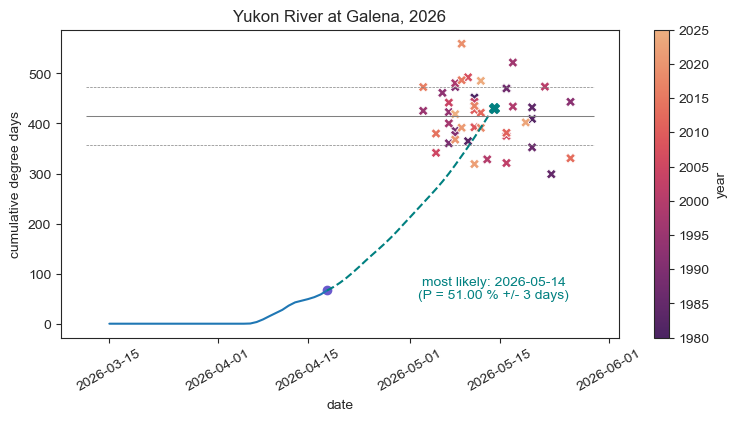

In [ ]:
theyear = str(2026)

fig = plt.subplots(figsize=(9, 4))
f = sns.lineplot(data=testdd[f'{theyear}-03-15':today], x='thedate', y=theyear, )
f2 = sns.lineplot(data=testdd[today:forecasted_date], x='thedate', y=theyear, linestyle='--', color='teal', legend=None)
g = sns.scatterplot(data=breakupdd25DF, x='thedate', y='DD25', hue='year', palette='flare_r', s=50, marker="X", ax=f, legend=None)
plt.scatter(dt.datetime.strptime(today, '%Y-%m-%d'), testdd.loc[today][theyear], color='slateblue')
plt.scatter(dt.datetime.strptime(forecasted_date, '%Y-%m-%d'), testdd.loc[forecasted_date][theyear], color='teal', s=50, marker="X")
xmin, _  = f.get_xlim()
_, xmax = g.get_xlim()
norm = plt.Normalize(breakupdd25DF['year'].min(), breakupdd25DF['year'].max())
cmap = sns.color_palette("flare_r", as_cmap=True)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=f, label='year')
plt.hlines(y=meandd25, color='grey', xmin=xmin, xmax=xmax, lw=0.75,)
plt.hlines(y=[meandd25-stddd25, meandd25+stddd25], color='grey', linestyles='--', lw=0.5, xmin=xmin, xmax=xmax)
plt.xticks(rotation=30)
plt.xlabel('date')
plt.ylabel('cumulative degree days')
plt.title(f"{testsite}, {theyear}")
plt.text(dt.datetime.strptime(forecasted_date, '%Y-%m-%d'), 50, 
         f"most likely: {forecasted_date}\n(P = {likelihood_3d:.2f} % +/- 3 days)", color='teal', ha='center'  )
# sns.move_legend(f, "upper left")
fn = f'intermediate_cumul_{testsite.replace(' ', '_')}_{theyear}.png'
plt.savefig(fn, bbox_inches='tight')

### During season: read latest daily report and plot up to current date

In [ ]:
siteIDs

array(['Buckland River at Buckland', 'Colville River at Colville Village',
       'Colville River at Umiat', 'Kobuk River at Ambler',
       'Kobuk River at Kobuk', 'Kobuk River at Shungnak',
       'Koyukuk River at Allakaket', 'Koyukuk River at Bettles',
       'Koyukuk River at Hughes', 'Kuskokwim River at Akiak',
       'Kuskokwim River at Aniak', 'Kuskokwim River at Bethel',
       'Kuskokwim River at Crooked Creek', 'Kuskokwim River at Kalskag',
       'Kuskokwim River at McGrath', 'Kuskokwim River at Napakiak',
       'Kuskokwim River at Nikolai', 'Kuskokwim River at Red Devil',
       'Kuskokwim River at Sleetmute', 'Kuskokwim River at Stony River',
       'Kuskokwim River at Tuluksak', 'Susitna River at Sunshine',
       'Tanana River at Fairbanks D-S of Chena R',
       'Tanana River at Nenana', 'Tanana River nr Manley Hot Springs',
       'Yukon River at Alakanuk', 'Yukon River at Anvik',
       'Yukon River at Beaver', 'Yukon River at Circle',
       'Yukon River at Dawson'

Processing Buckland River at Buckland...


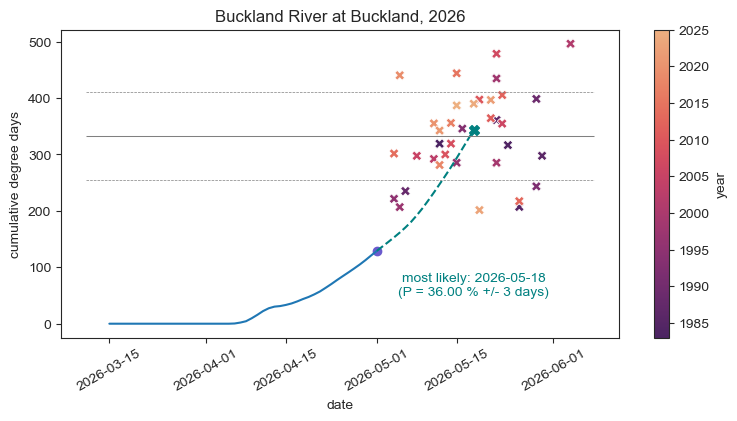

Processing Colville River at Colville Village...


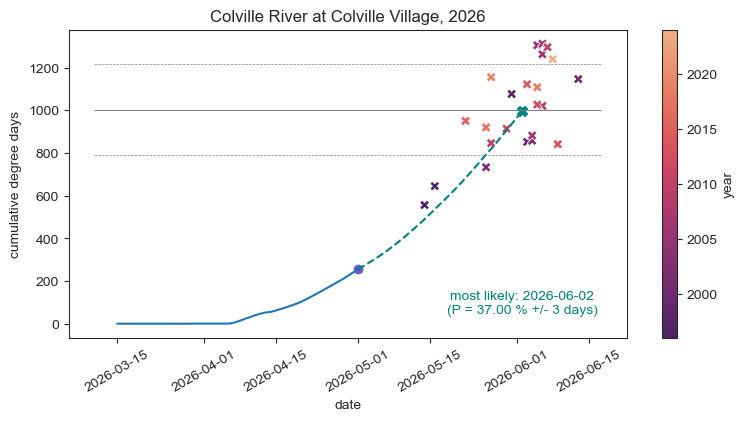

Processing Colville River at Umiat...


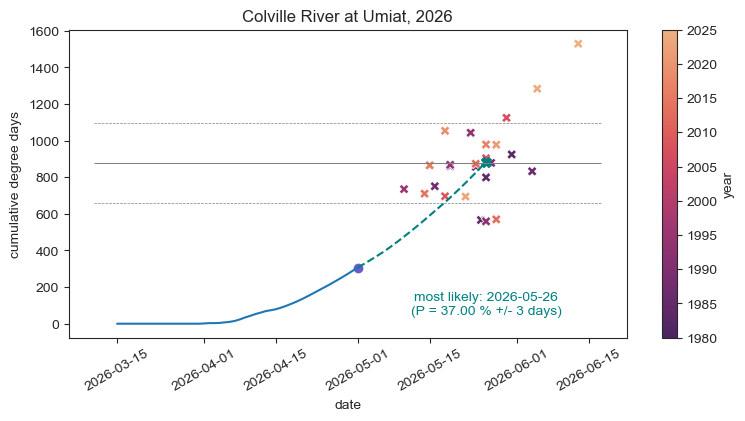

Processing Kobuk River at Ambler...


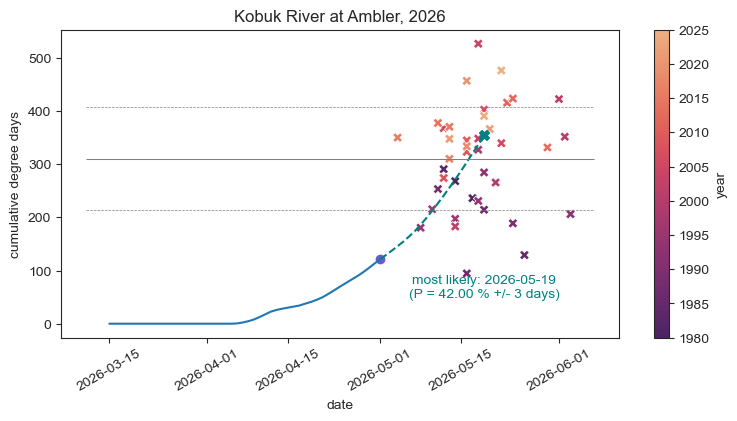

Processing Kobuk River at Kobuk...


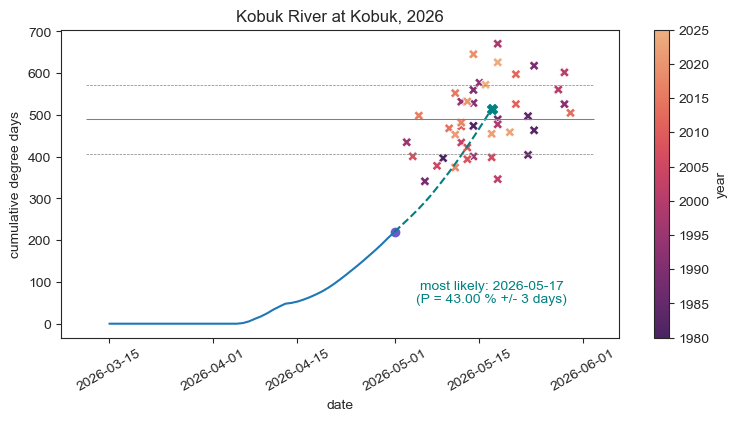

Processing Kobuk River at Shungnak...


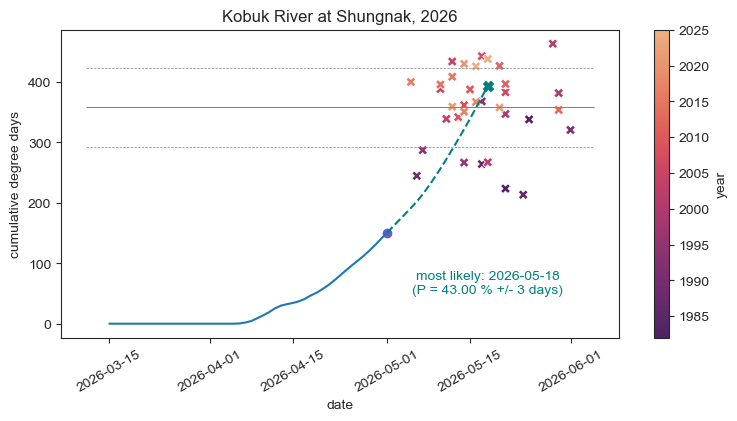

Processing Koyukuk River at Allakaket...


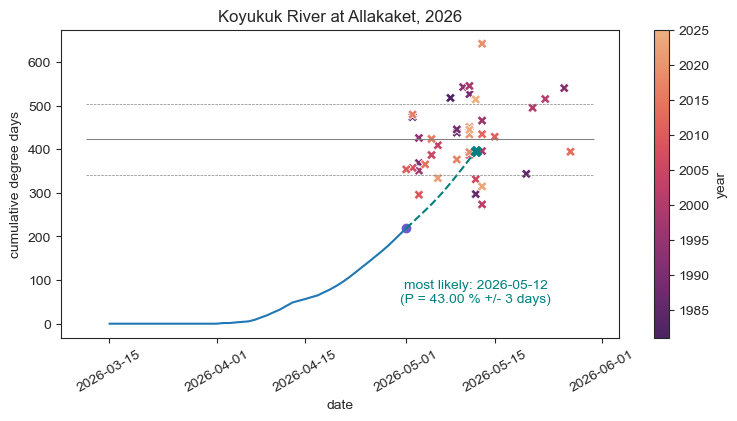

Processing Koyukuk River at Bettles...


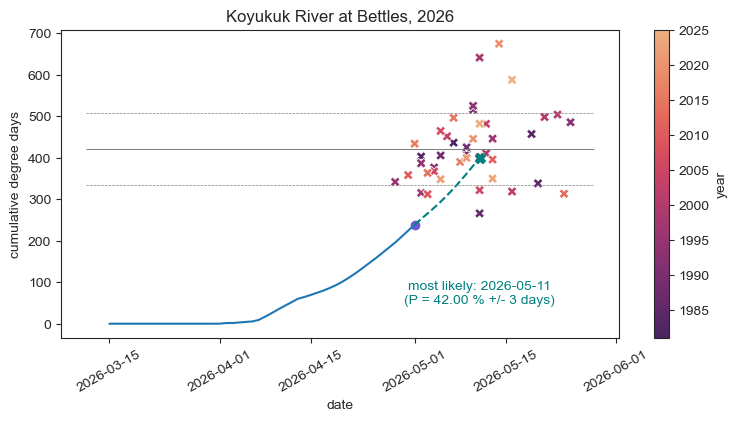

Processing Koyukuk River at Hughes...


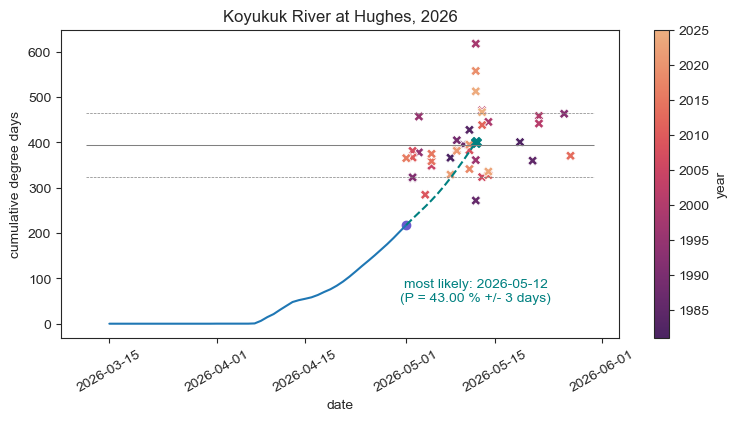

Processing Kuskokwim River at Akiak...


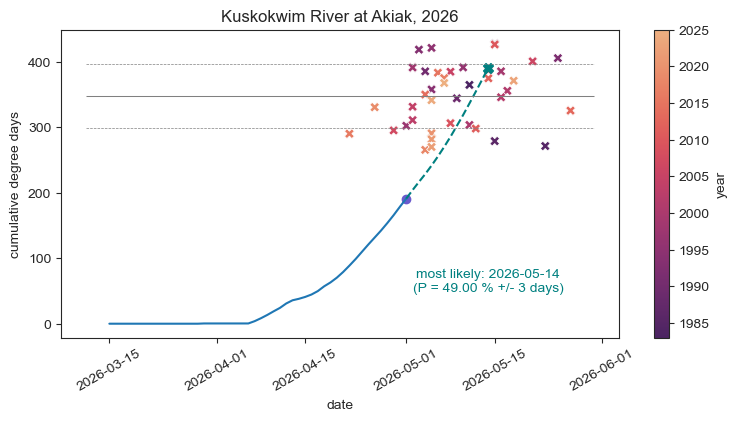

Processing Kuskokwim River at Aniak...


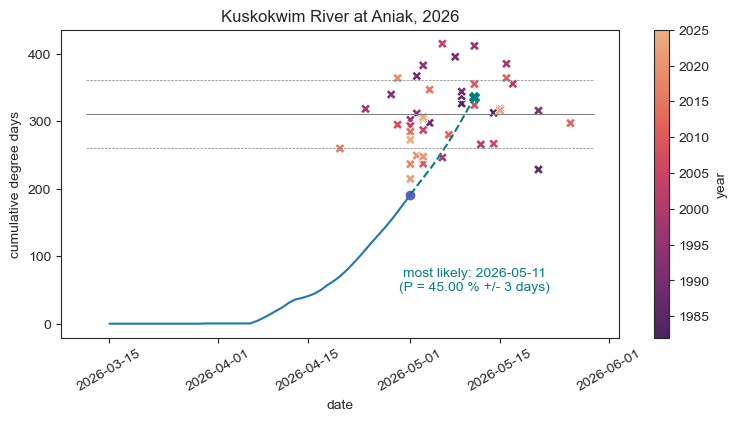

Processing Kuskokwim River at Bethel...


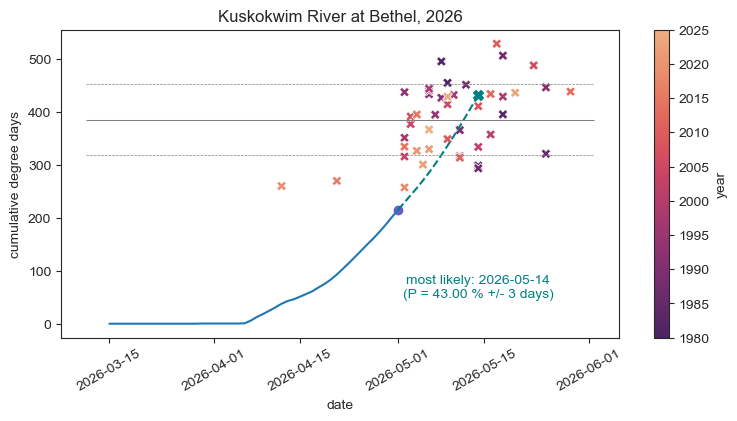

Processing Kuskokwim River at Crooked Creek...


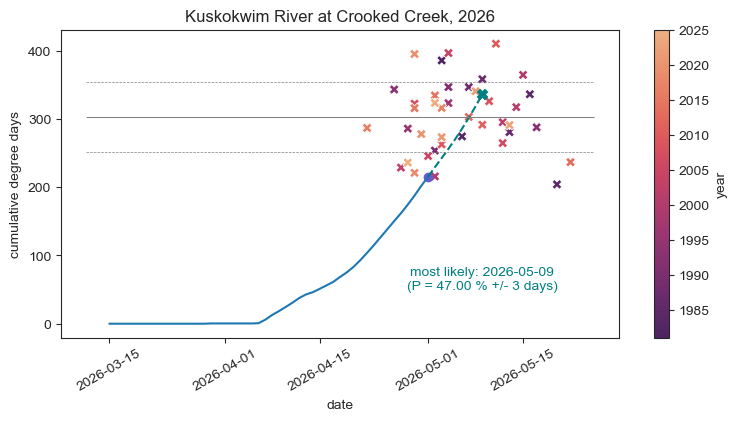

Processing Kuskokwim River at Kalskag...


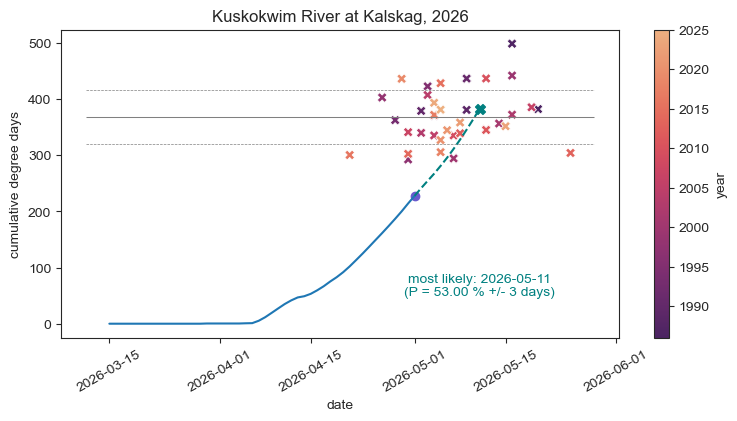

Processing Kuskokwim River at McGrath...


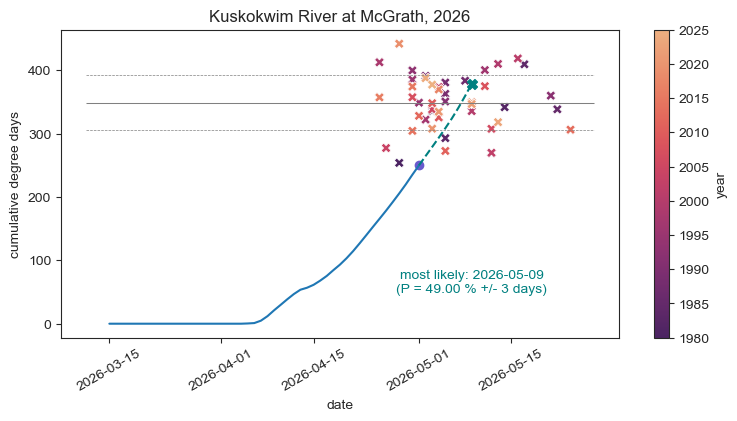

Processing Kuskokwim River at Napakiak...


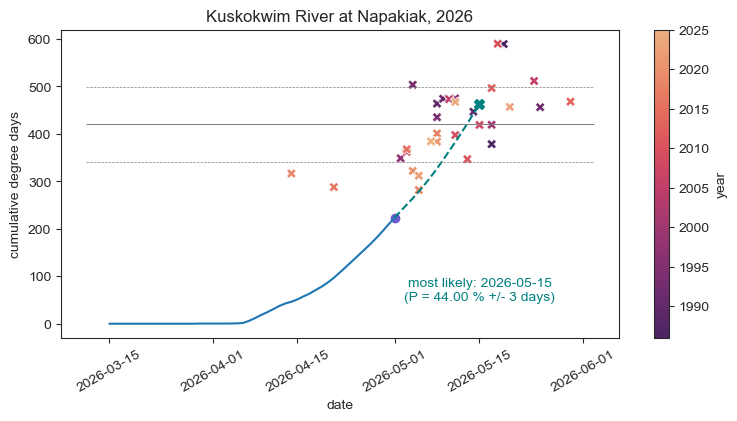

Processing Kuskokwim River at Nikolai...


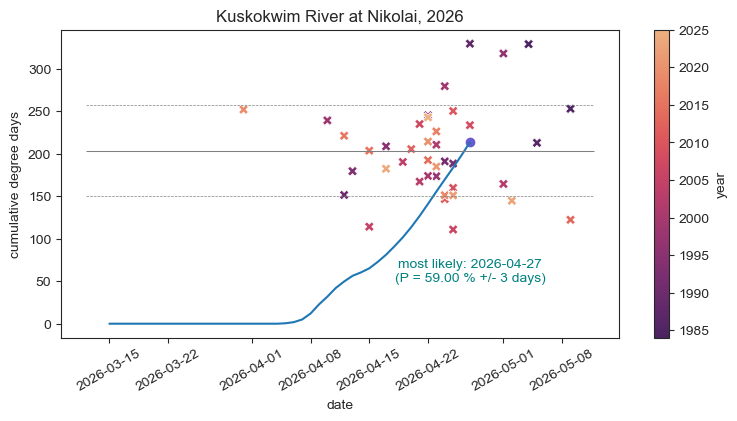

Processing Kuskokwim River at Red Devil...


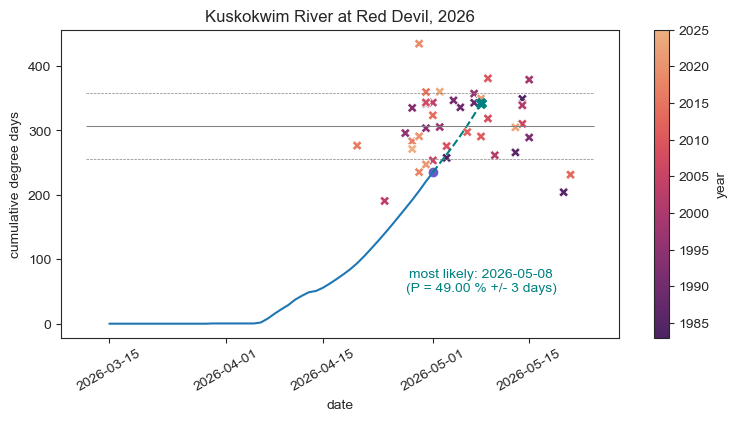

Processing Kuskokwim River at Sleetmute...


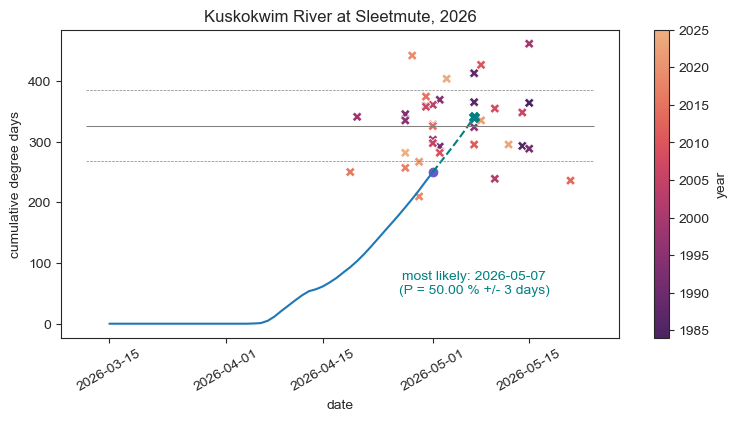

Processing Kuskokwim River at Stony River...


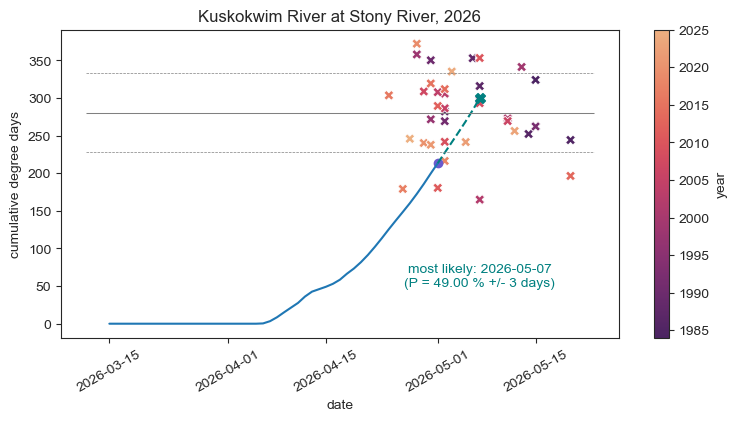

Processing Kuskokwim River at Tuluksak...


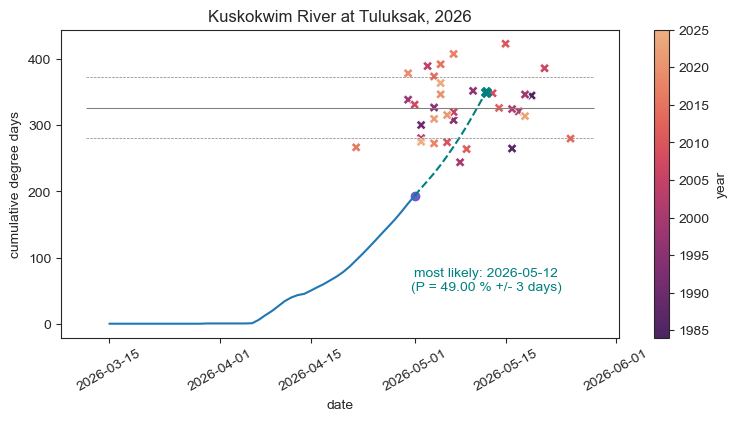

Processing Susitna River at Sunshine...


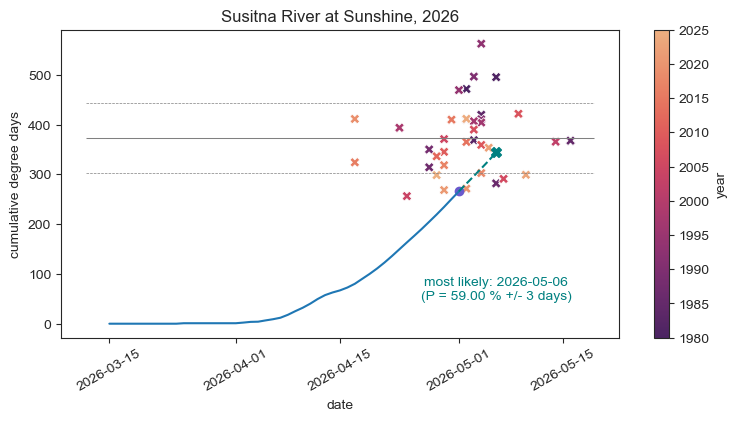

Processing Tanana River at Fairbanks D-S of Chena R...


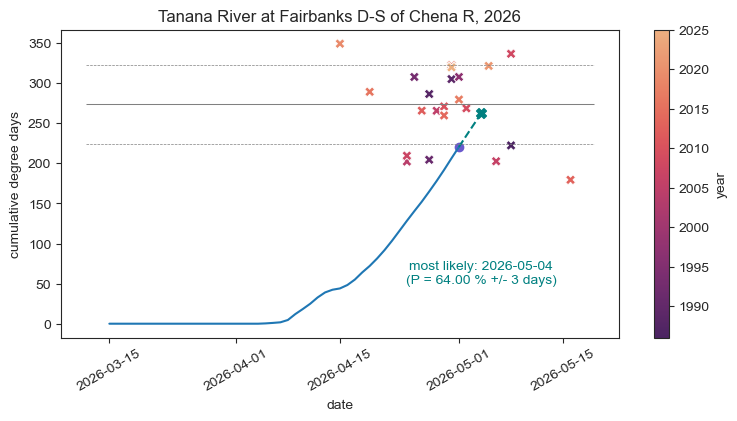

Processing Tanana River at Nenana...


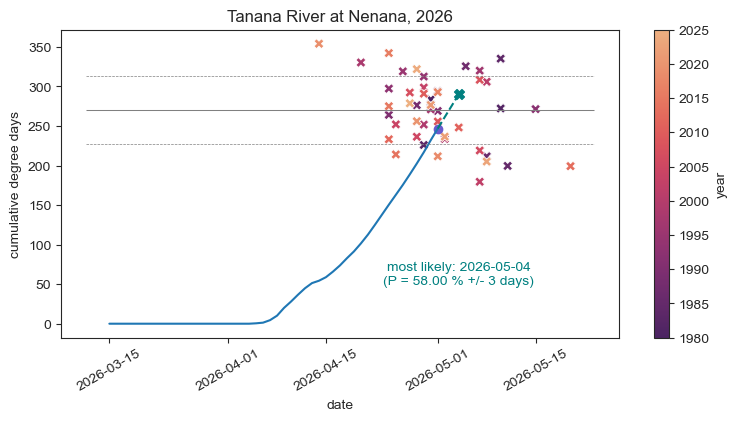

Processing Tanana River nr Manley Hot Springs...


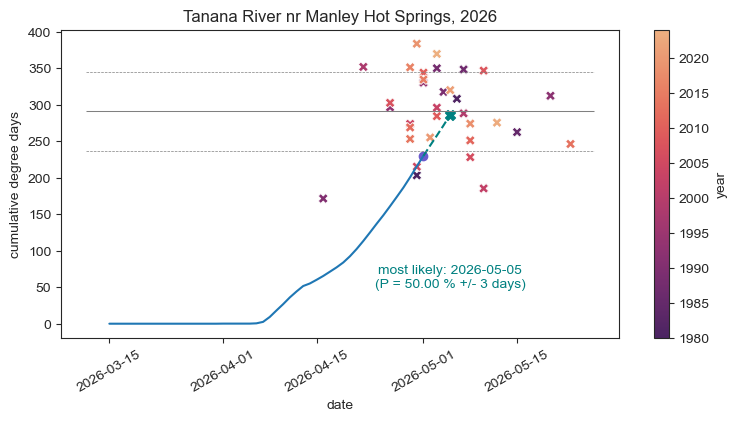

Processing Yukon River at Alakanuk...


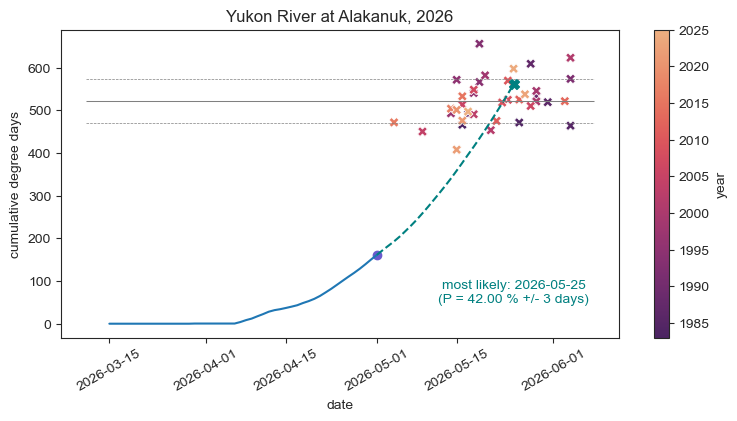

Processing Yukon River at Anvik...


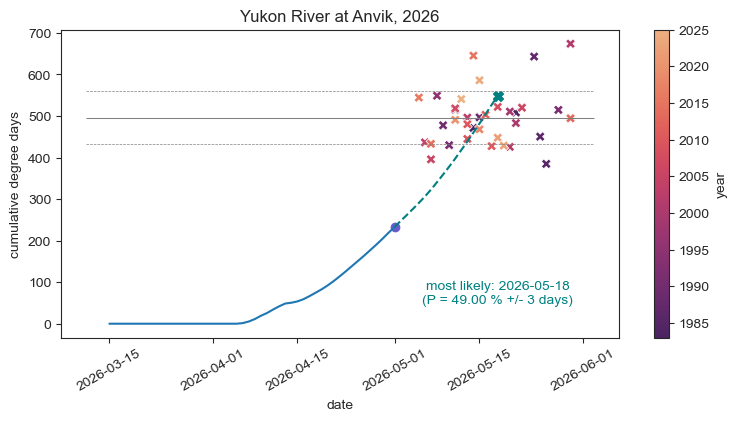

Processing Yukon River at Beaver...


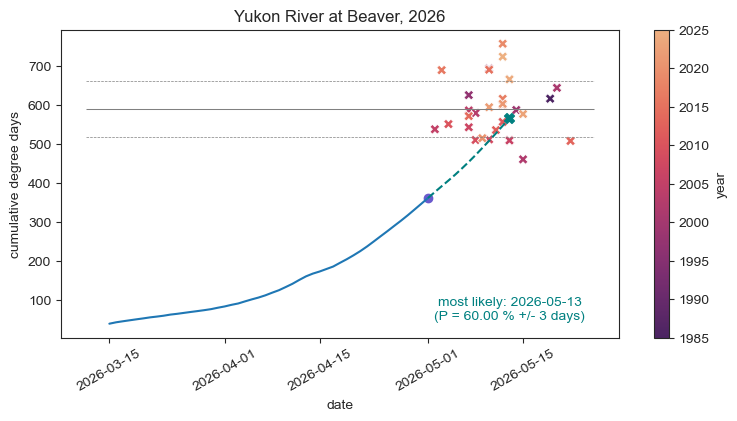

Processing Yukon River at Circle...


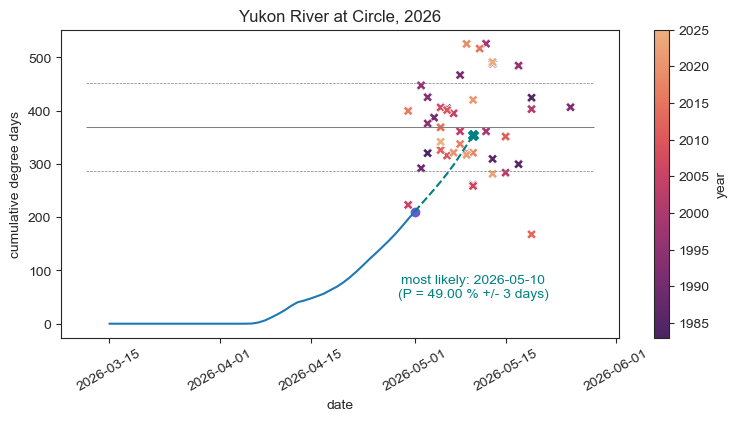

Processing Yukon River at Dawson...


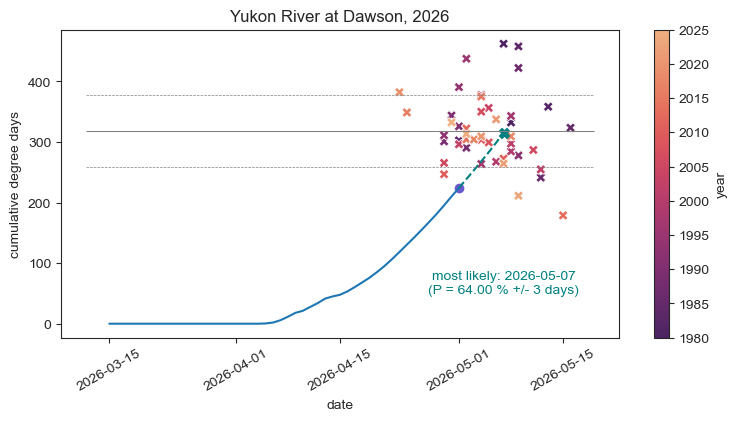

Processing Yukon River at Eagle...


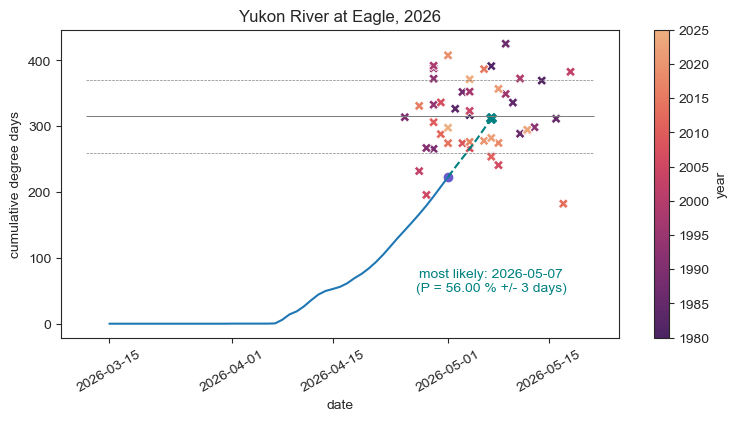

Processing Yukon River at Fort Yukon...


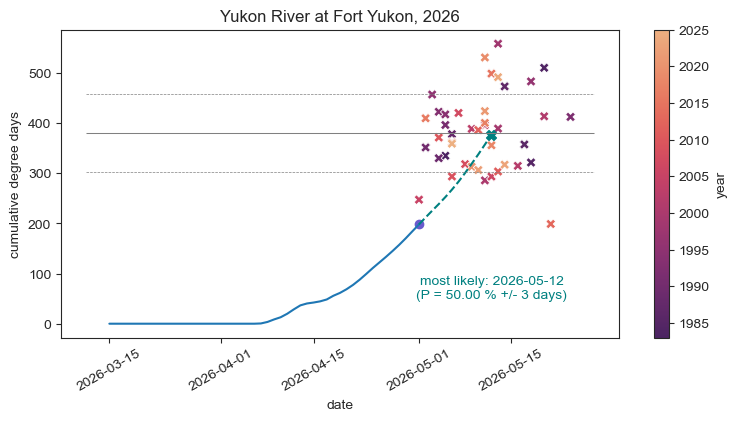

Processing Yukon River at Galena...


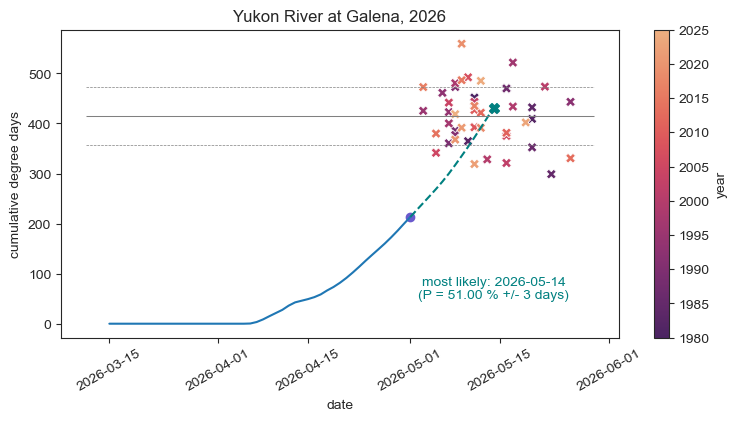

Processing Yukon River at Holy Cross...


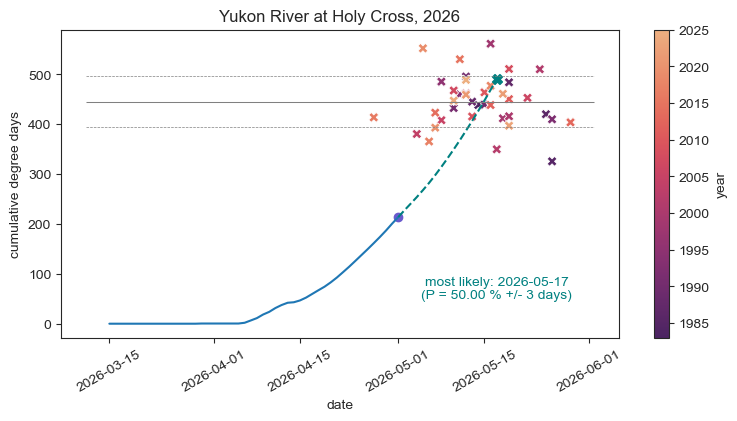

Processing Yukon River at Kaltag...


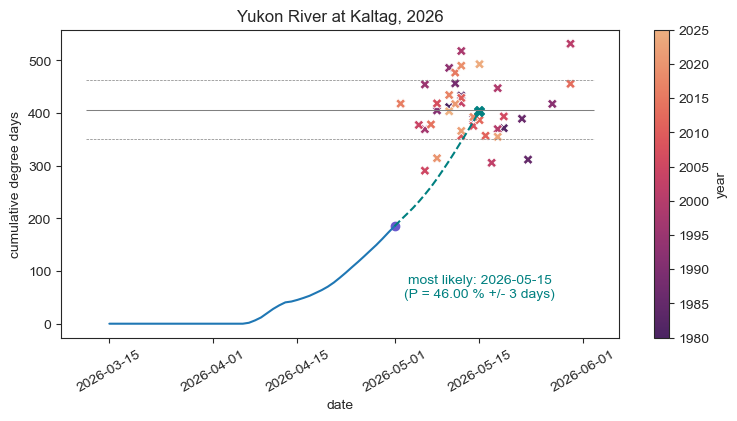

Processing Yukon River at Marshall...


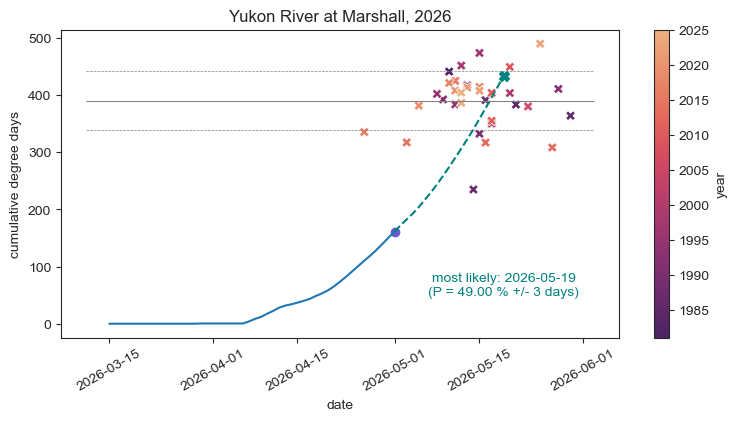

Processing Yukon River at Mountain Village...


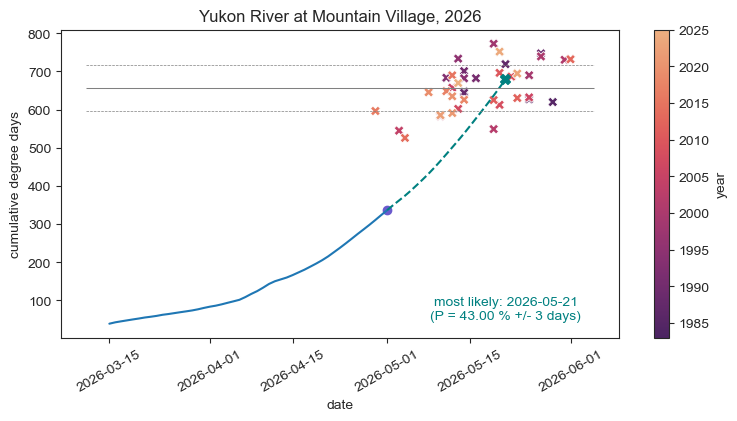

Processing Yukon River at Nulato...


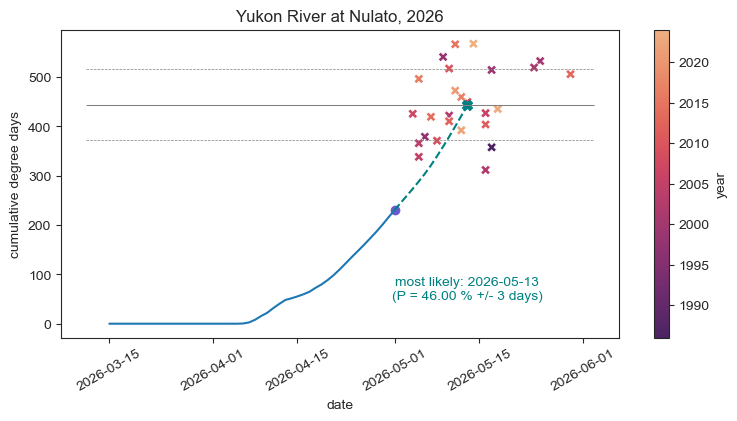

Processing Yukon River at Pilot Station...


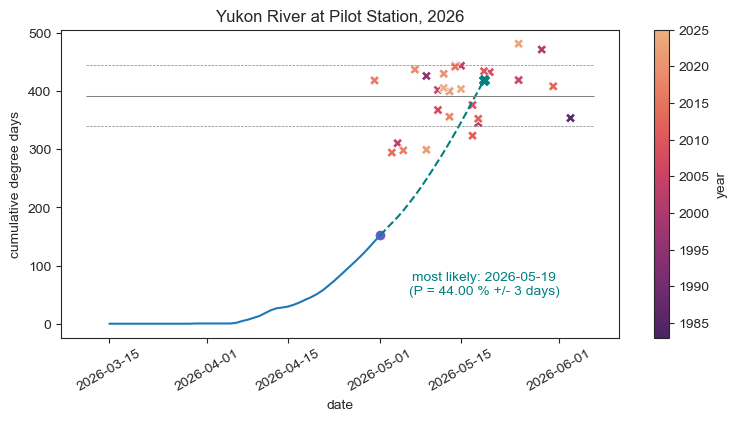

Processing Yukon River at Rampart...


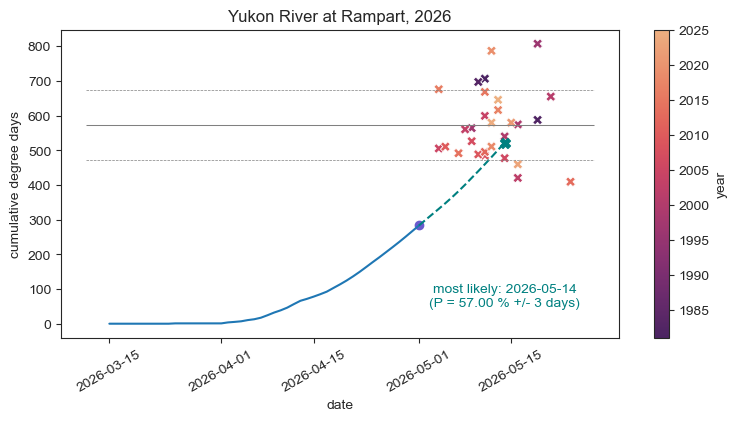

Processing Yukon River at Ruby...


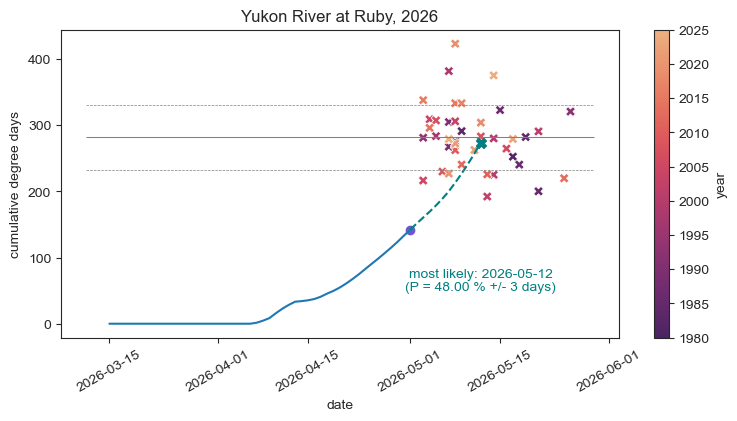

Processing Yukon River at Russian Mission...


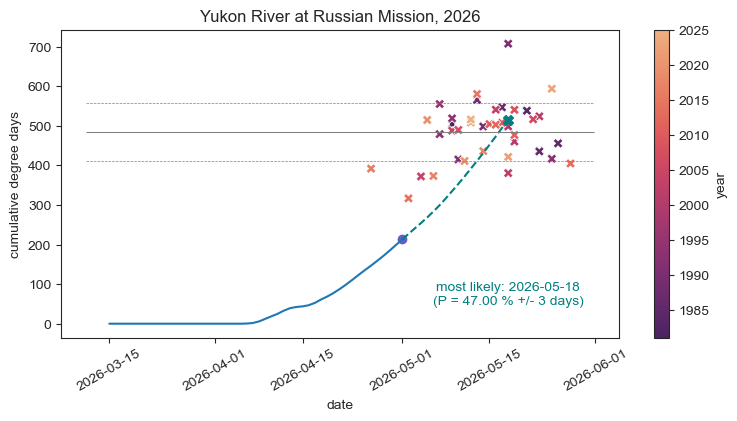

Processing Yukon River at Stevens Village...


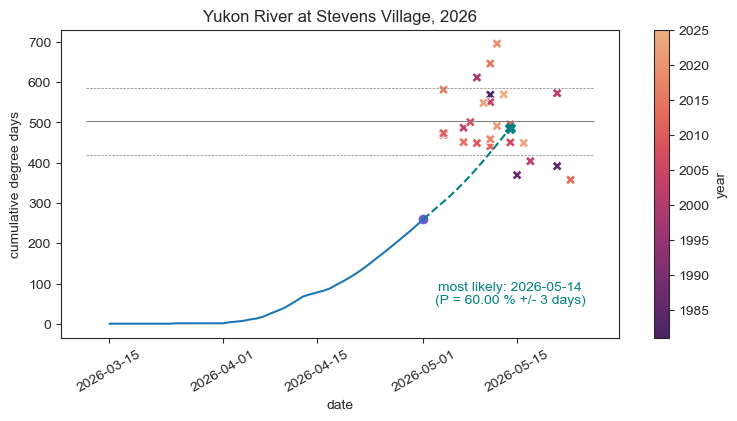

Processing Yukon River at Tanana...


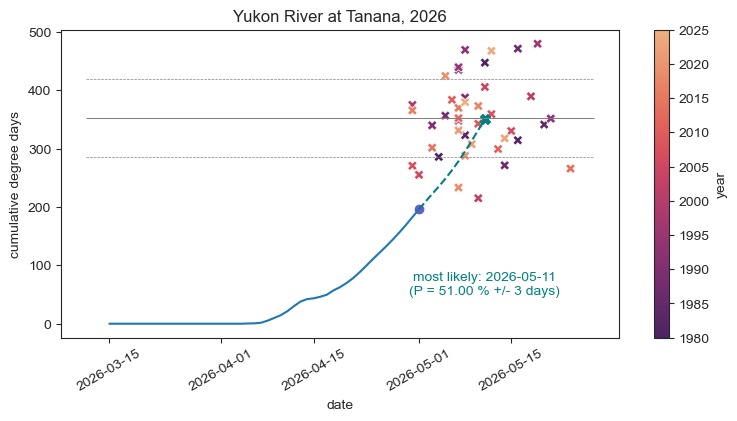

Processing Yukon River nr Emmonak...


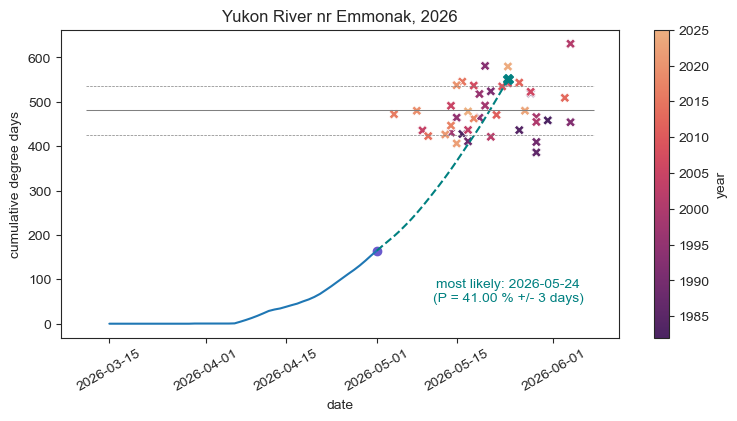

In [ ]:
theyear = str(2026)
save_figures = False  # True: display plots in notebook, False: save PNG files
today_dt = pd.to_datetime(today)
for site in siteIDs:
    print(f"Processing {site}...")
    testdd = get_testdd(site)
    breakupdd25DF = get_breakupdd25DF(site, theyear)
    forecasted_date, likelihood_3d = get_dailyreport_items(site)
    forecast_dt = pd.to_datetime(forecasted_date)
    plot_end = min(today_dt, forecast_dt).strftime('%Y-%m-%d')
    meandd25, stddd25 = breakupdd25DF.DD25.mean(), breakupdd25DF.DD25.std()
    testdd['thedate'] = pd.to_datetime(testdd.julian_day-1, unit='D',
                   origin=pd.Timestamp(f'{theyear}-01-01'))
    testdd.set_index('thedate', inplace=True)
    
    fig, ax = plt.subplots(figsize=(9, 4))
    f = sns.lineplot(data=testdd[f'{theyear}-03-15':plot_end], x='thedate', y=theyear, ax=ax)
    g = sns.scatterplot(data=breakupdd25DF, x='thedate', 
                        y='DD25', hue='year', palette='flare_r', s=50, marker="X", ax=ax, legend=None)
    
    if forecast_dt > today_dt:
        sns.lineplot(data=testdd[today:forecasted_date], x='thedate', 
                     y=theyear, linestyle='--', color='teal', legend=None, ax=ax)
        ax.scatter(forecast_dt, testdd.loc[forecasted_date][theyear], color="teal", s=50, marker="X")
        ax.scatter(today_dt, testdd.loc[today][theyear], color="slateblue")
    else:
        ax.scatter(forecast_dt, testdd.loc[forecast_dt][theyear], color="slateblue")
    xmin, _ = f.get_xlim()
    _, xmax = g.get_xlim()
    norm = plt.Normalize(breakupdd25DF['year'].min(), breakupdd25DF['year'].max())
    cmap = sns.color_palette("flare_r", as_cmap=True)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='year')
    ax.hlines(y=meandd25, color='grey', xmin=xmin, xmax=xmax, lw=0.75)
    ax.hlines(y=[meandd25-stddd25, meandd25+stddd25], color='grey', linestyles='--', lw=0.5, xmin=xmin, xmax=xmax)
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel('date')
    ax.set_ylabel('cumulative degree days')
    ax.set_title(f"{site}, {theyear}")
    ax.text(dt.datetime.strptime(forecasted_date, '%Y-%m-%d'), 50,
            f"most likely: {forecasted_date}\n(P = {likelihood_3d:.2f} % +/- 3 days)", color='teal', ha='center')
    # sns.move_legend(f, "upper left")
    fn = f'intermediate_cumul_{site.replace(' ', '_')}_{theyear}.png'

    if save_figures:
        fig.savefig(fn, bbox_inches='tight')
    else:
        plt.show()

    plt.close(fig)

### 2025 - end of season: loop through locations in broken_up file

Yukon River at Dawson broke up on 2025-04-30
Yukon River at Eagle broke up on 2025-05-01
Yukon River at Circle broke up on 2025-05-05
Yukon River at Fort Yukon broke up on 2025-05-06
Kuskokwim River at Nikolai broke up on 2025-04-22
Kuskokwim River at McGrath broke up on 2025-05-03
Yukon River at Galena broke up on 2025-05-08
Kuskokwim River at Crooked Creek broke up on 2025-04-28
Kuskokwim River at Sleetmute broke up on 2025-04-27
Kuskokwim River at Stony River broke up on 2025-04-27
Kuskokwim River at Red Devil broke up on 2025-04-28
Kuskokwim River at Akiak broke up on 2025-05-07
Kuskokwim River at Aniak broke up on 2025-05-01
Kuskokwim River at Kalskag broke up on 2025-05-05
Kuskokwim River at Tuluksak broke up on 2025-05-02
Kuskokwim River at Bethel broke up on 2025-05-06
Tanana River at Nenana broke up on 2025-04-27


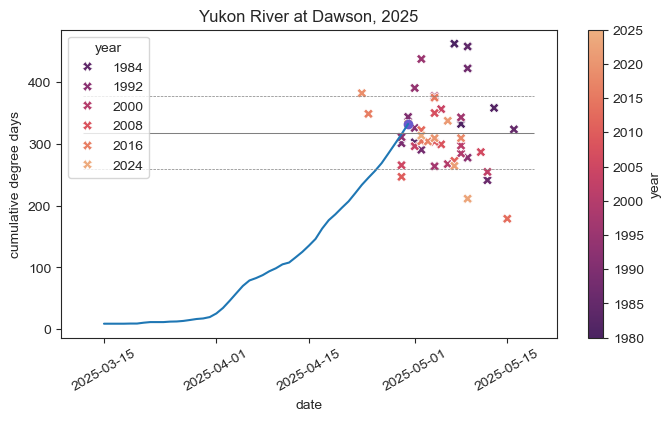

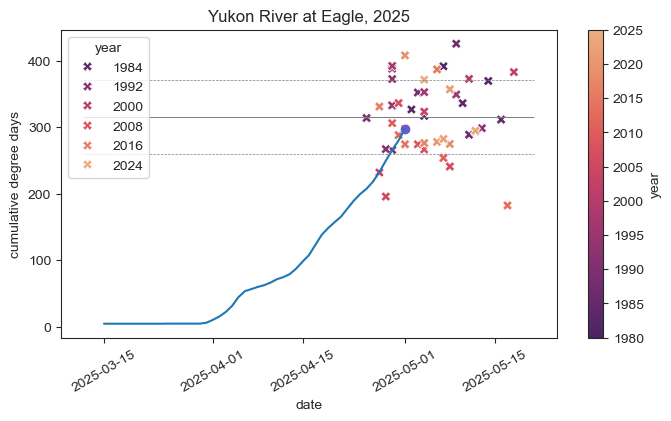

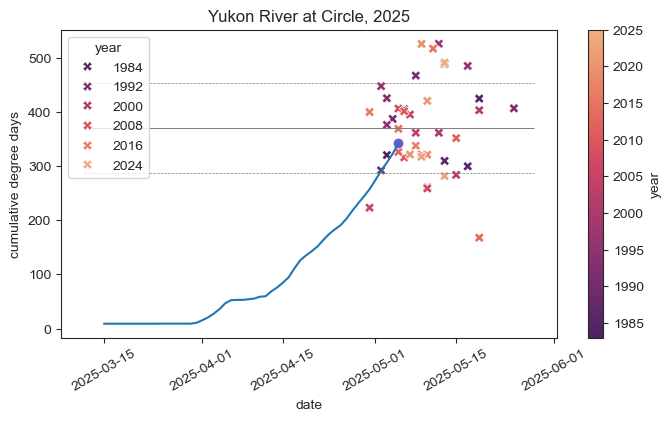

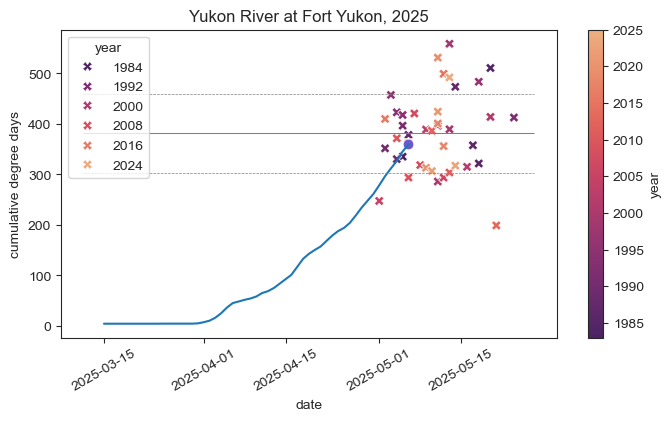

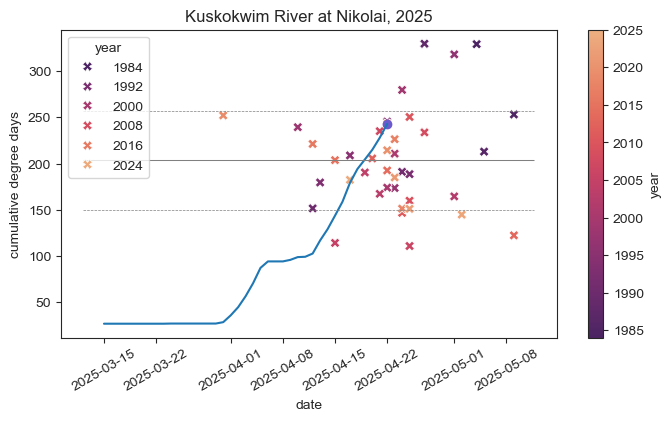

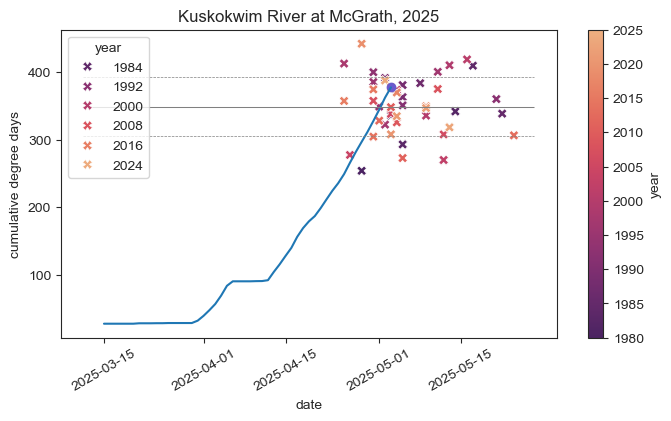

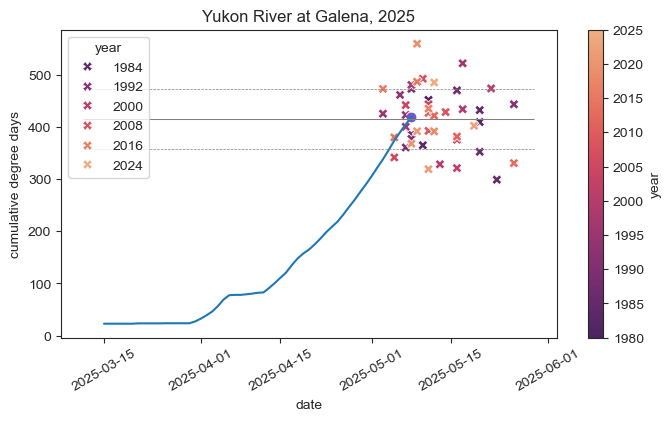

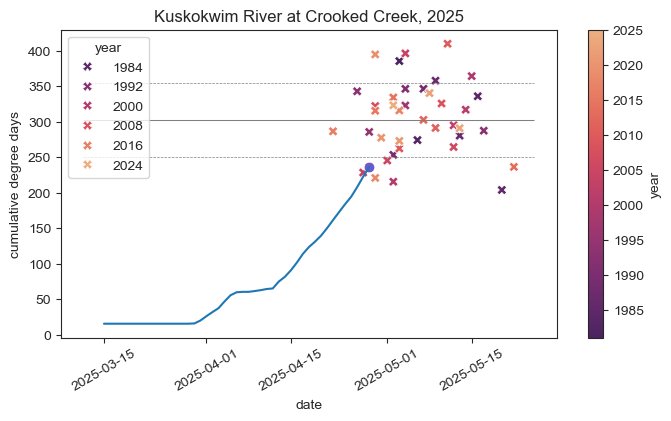

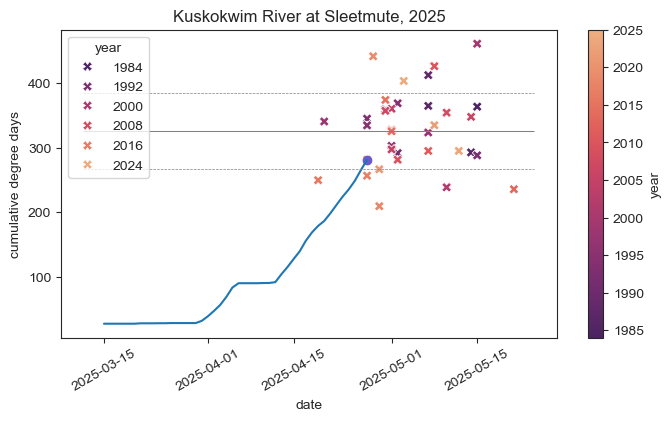

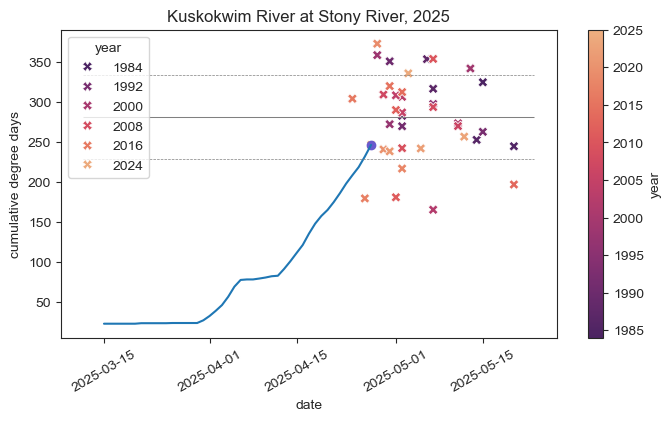

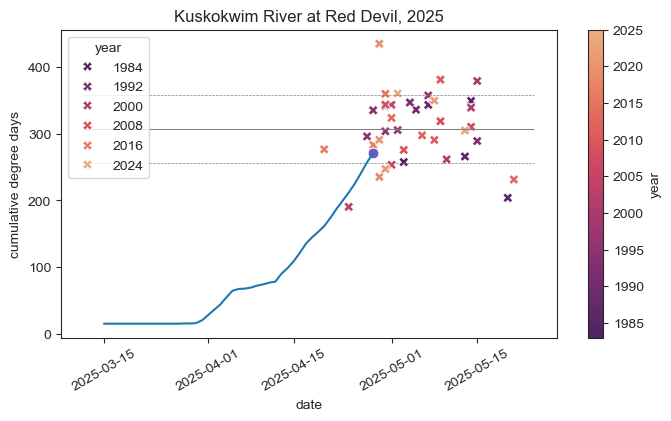

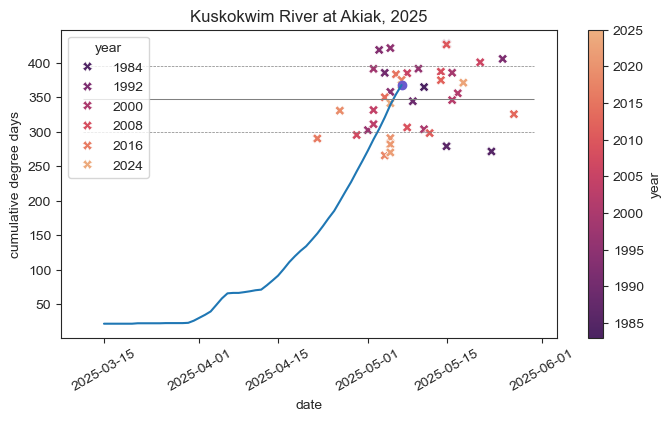

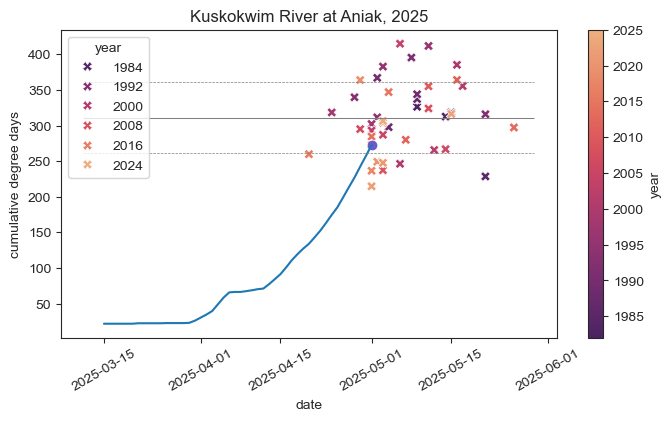

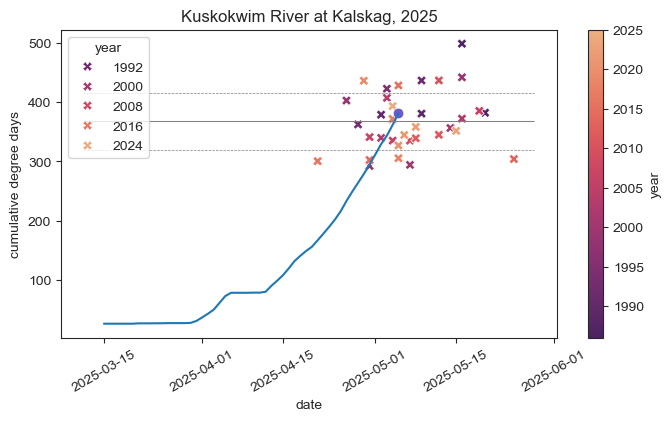

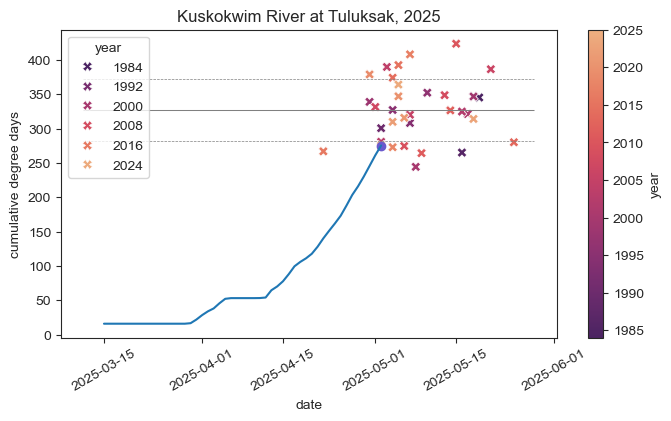

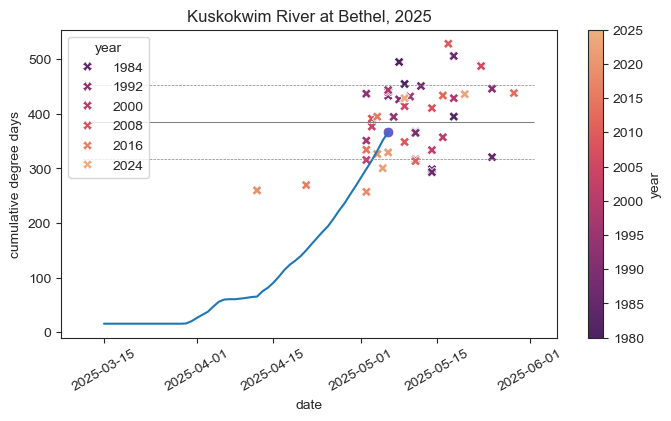

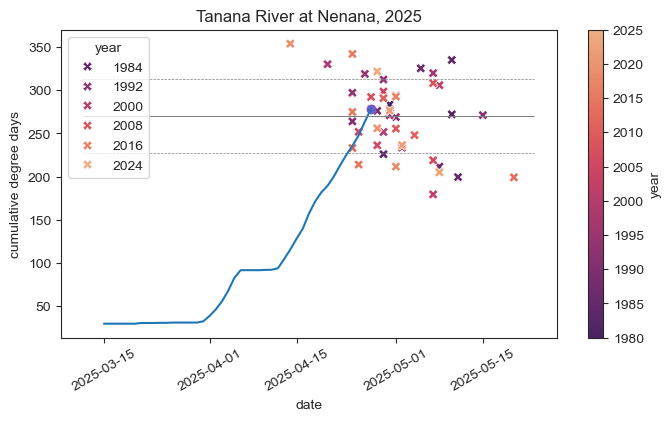

In [ ]:
theyear = str(2025)

for location, actualbreakup in broken_up.itertuples():
    print(location, "broke up on", actualbreakup)
    # load the combined DD25 averages for location
    testdd = pd.read_csv(combindedpth / f"{locationprefix}{location.replace(' ', '_')}.csv", skiprows=3)
    testdd_melted = testdd.melt(id_vars=['julian_day'], value_vars=testdd.columns[1:], var_name='year', value_name='dd25')
    testdd_melted.set_index(['julian_day', 'year'], inplace=True)
    # load historical breakupdate / DD25 values
    breakupdd25 = []
    for _, year, JulianDay in  breakup[breakup.siteID==location][['year', 'JulianDay']].itertuples():
        breakupdd25.append([year, JulianDay, testdd_melted.loc[(JulianDay, str(year)), 'dd25']])
    breakupdd25DF = pd.DataFrame(breakupdd25)
    breakupdd25DF.columns = ['year', 'JulianDay', 'DD25']
    breakupdd25DF['thedate'] = pd.to_datetime(breakupdd25DF.JulianDay-1, unit='D',
                origin=pd.Timestamp(f'{theyear}-01-01'))
    # get mean and standard deviation of historical data
    meandd25, stddd25 = breakupdd25DF.DD25.mean(), breakupdd25DF.DD25.std()
    # make a datetime index for plotting of time series
    testdd['thedate'] = pd.to_datetime(testdd.julian_day-1, unit='D',
               origin=pd.Timestamp(f'{theyear}-01-01'))
    testdd.set_index('thedate', inplace=True)
    # plot and save figure 
    fig = plt.subplots(figsize=(8, 4))
    f = sns.lineplot(data=testdd[f'{theyear}-03-15':actualbreakup], x='thedate', y=theyear, )
    g = sns.scatterplot(data=breakupdd25DF, x='thedate', y='DD25', hue='year', palette='flare_r', s=50, marker="X", ax=f)
    norm = plt.Normalize(breakupdd25DF['year'].min(), breakupdd25DF['year'].max())
    cmap = sns.color_palette("flare_r", as_cmap=True)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=f, label='year')
    # sns.move_legend(f, "upper left")
    plt.scatter(dt.datetime.strptime(actualbreakup, '%Y-%m-%d'), testdd.loc[actualbreakup][theyear], color='slateblue')
    xmin, _  = f.get_xlim()
    _, xmax = g.get_xlim()
    plt.hlines(y=meandd25, color='grey', xmin=xmin, xmax=xmax, lw=0.75,)
    plt.hlines(y=[meandd25-stddd25, meandd25+stddd25], color='grey', linestyles='--', lw=0.5, xmin=xmin, xmax=xmax)
    plt.xticks(rotation=30)
    plt.xlabel('date')
    plt.ylabel('cumulative degree days')
    plt.title(f"{location}, {theyear}")

    fn = f'final_cumul_{location.replace(' ', '_')}_{theyear}.png'
    plt.savefig(fn, bbox_inches='tight')
    
